# 2. Análisis Exploratorio

In [5]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
# import statsmodels.stats.diagnostic as diag
# import statsmodels.api as sm

In [44]:
# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None)
# Configuración para mostrar todas las filas
pd.set_option('display.max_rows', None)

In [6]:
datos = pd.read_csv('train.csv', sep=',', low_memory=False)
datos.shape
datos.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [46]:
#Resumen del set de datos
datos.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [47]:
datos.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [48]:
#print(datos.info())

# Recuento de valores nulos
print(datos.isnull().sum())

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

## 2.1 Tipos de datos y estructura general

In [49]:
# Separar variables numéricas y categóricas
numericas = datos.select_dtypes(include=[np.number]).columns.tolist()
categoricas = datos.select_dtypes(include=['object']).columns.tolist()

print(f"Total de variables: {datos.shape[1]}")
print(f"Total de registros: {datos.shape[0]}")
print(f"\nVariables numéricas ({len(numericas)}):")
print(numericas)
print(f"\nVariables categóricas ({len(categoricas)}):")
print(categoricas)

Total de variables: 81
Total de registros: 1460

Variables numéricas (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables categóricas (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Ce

/tmp/ipykernel_22954/3977002767.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = datos.select_dtypes(include=['object']).columns.tolist()


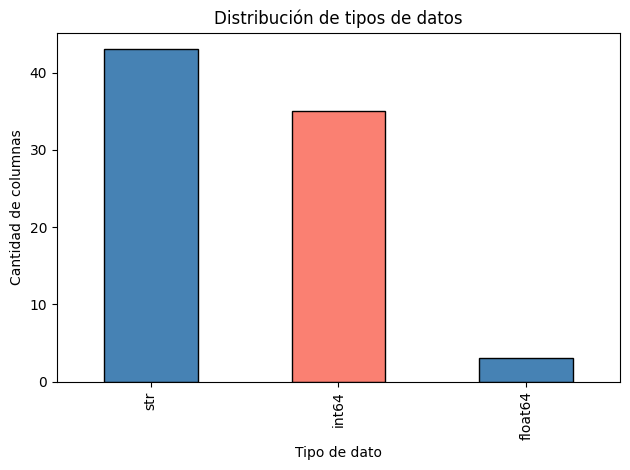

In [50]:
# Tipos de datos de cada columna
datos.dtypes.value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Distribución de tipos de datos')
plt.xlabel('Tipo de dato')
plt.ylabel('Cantidad de columnas')
plt.tight_layout()
plt.show()

## 2.2 Análisis de valores nulos

In [51]:
# Porcentaje de valores nulos por columna
nulos = datos.isnull().sum()
porcentaje_nulos = (nulos / len(datos) * 100).round(2)

# Filtrar solo columnas con nulos
nulos_df = pd.DataFrame({
    'Valores Nulos': nulos[nulos > 0],
    'Porcentaje (%)': porcentaje_nulos[porcentaje_nulos > 0]
}).sort_values('Porcentaje (%)', ascending=False)

print(f"Columnas con valores nulos: {len(nulos_df)} de {datos.shape[1]}")
nulos_df

Columnas con valores nulos: 19 de 81


,Valores Nulos,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


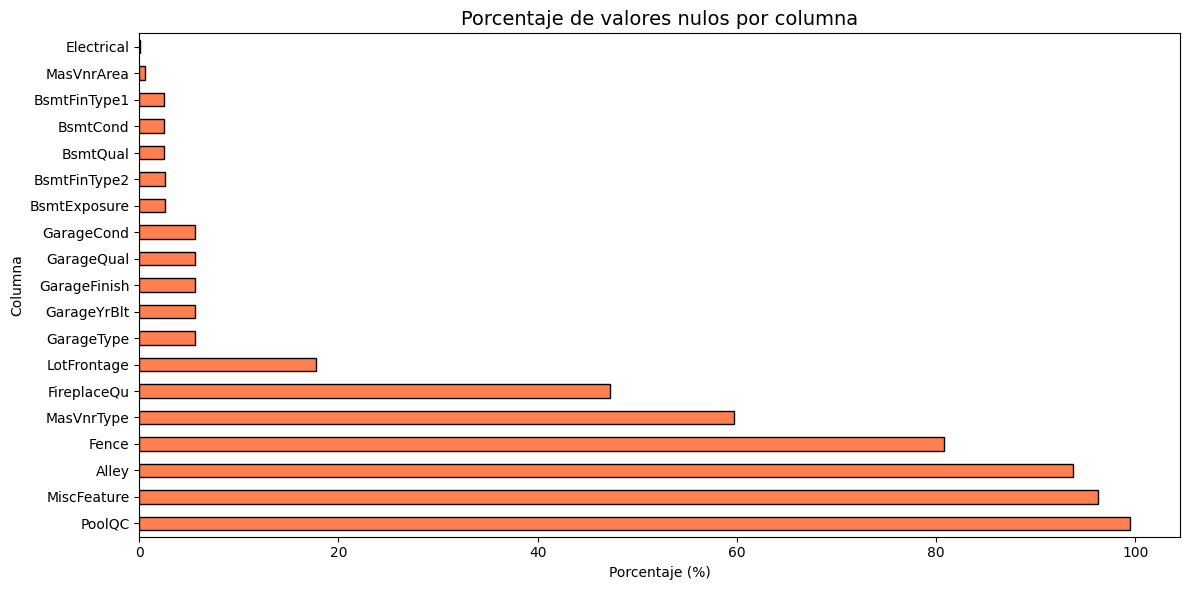

In [52]:
# Visualización de valores nulos
fig, ax = plt.subplots(figsize=(12, 6))
nulos_df['Porcentaje (%)'].plot(kind='barh', color='coral', edgecolor='black', ax=ax)
ax.set_title('Porcentaje de valores nulos por columna', fontsize=14)
ax.set_xlabel('Porcentaje (%)')
ax.set_ylabel('Columna')
plt.tight_layout()
plt.show()

## 2.3 Distribución de variables numéricas

In [53]:
# Estadísticas descriptivas completas de variables numéricas
desc = datos[numericas].describe().T
desc['skewness'] = datos[numericas].skew()
desc['kurtosis'] = datos[numericas].kurtosis()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0,0.00,-1.20
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0,1.41,1.58
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0,2.16,17.45
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0,12.21,203.24
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0,0.22,0.10
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0,0.69,1.11
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0,-0.61,-0.44
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0,-0.50,-1.27
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0,2.67,10.08
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0,1.69,11.12


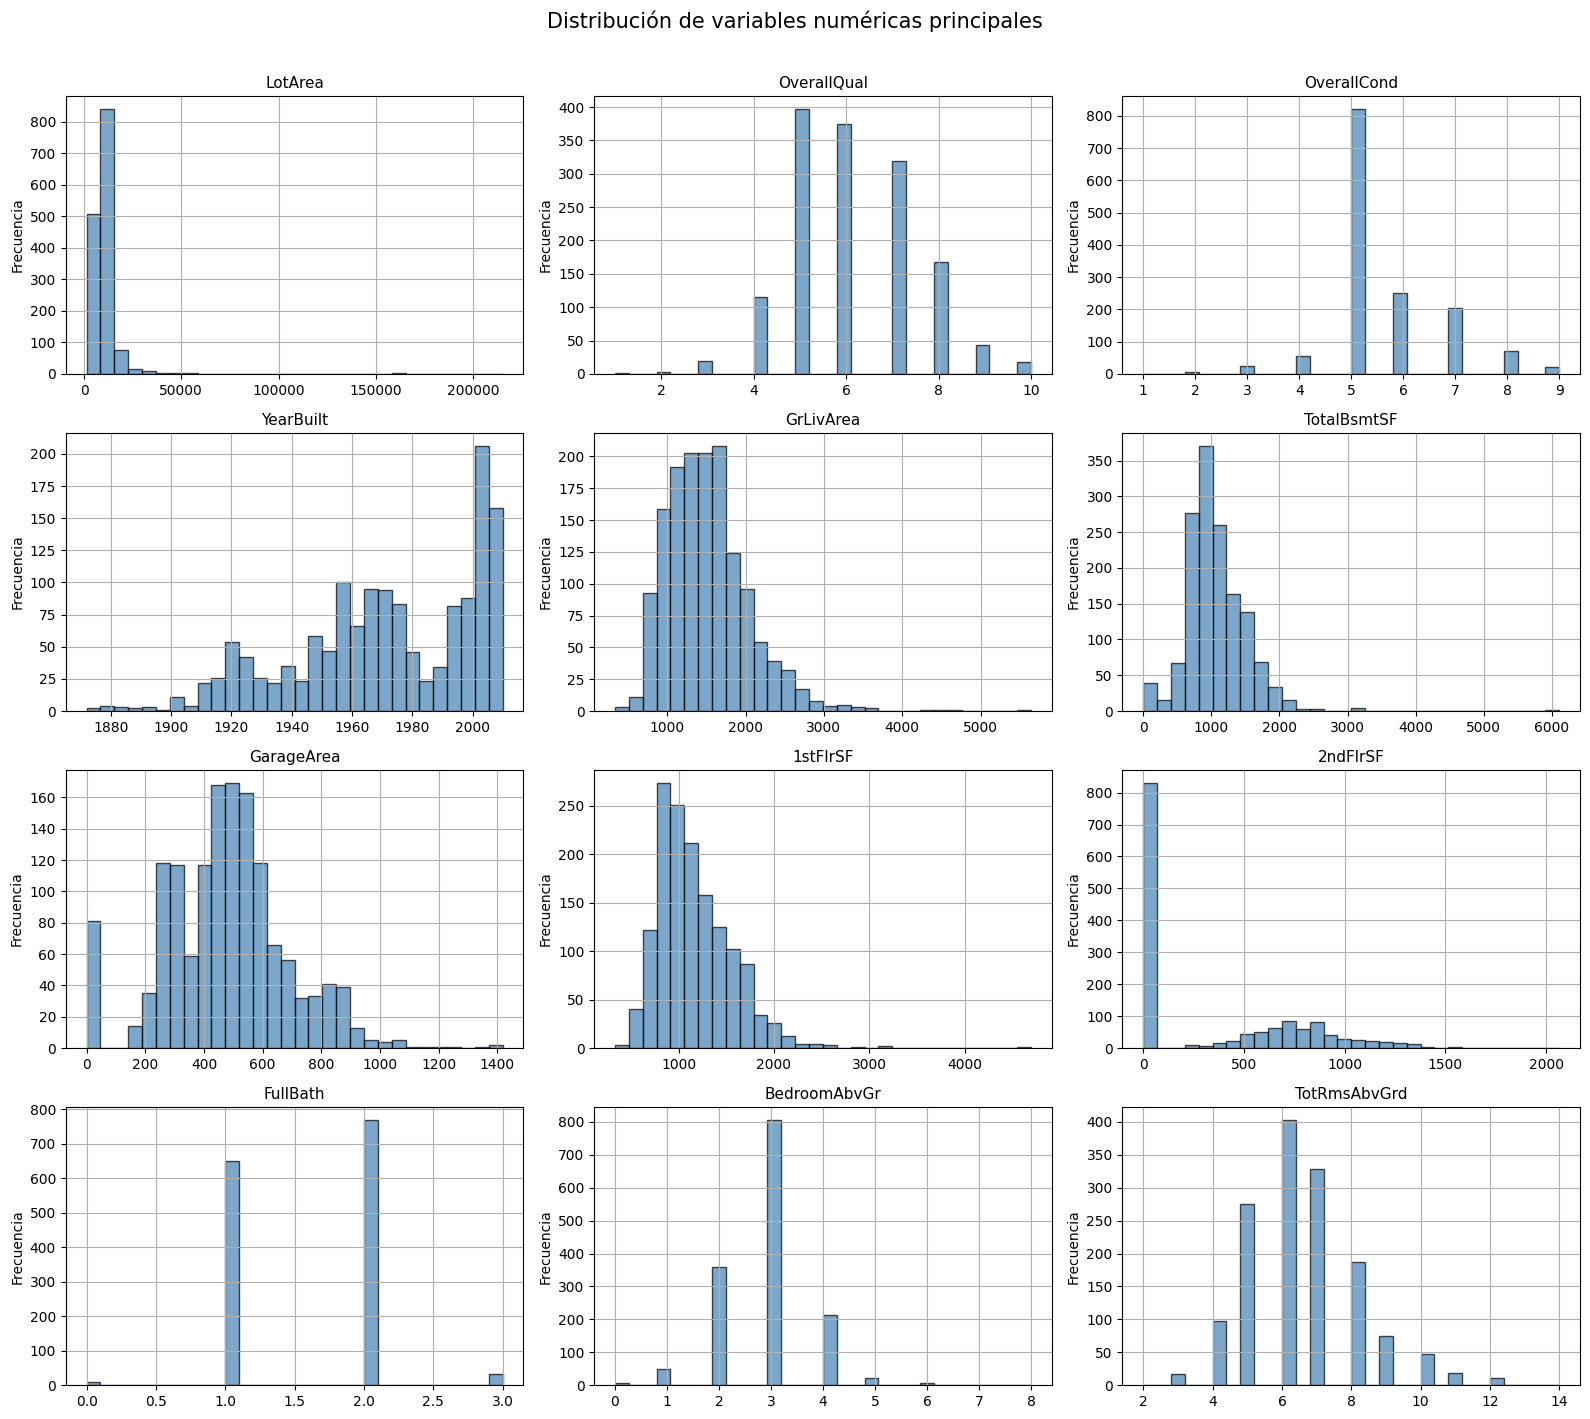

In [54]:
# Histogramas de variables numéricas principales
vars_principales = ['LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 
                     'GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF',
                     '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(vars_principales):
    datos[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas principales', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [56]:
# Test de normalidad (Shapiro-Wilk) para variables numéricas clave
vars_test = ['LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'YearBuilt']

print("Test de normalidad Shapiro-Wilk (H0: la distribución es normal)")
print("=" * 60)
for col in vars_test:
    muestra = datos[col].dropna()
    if len(muestra) > 5000:
        muestra = muestra.sample(5000, random_state=42)
    stat, p_value = stats.shapiro(muestra)
    resultado = "Normal" if p_value > 0.05 else "No Normal"
    print(f"{col:20s} | W={stat:.4f} | p-value={p_value:.6f} | {resultado}")

Test de normalidad Shapiro-Wilk (H0: la distribución es normal)
LotArea              | W=0.3511 | p-value=0.000000 | No Normal
GrLivArea            | W=0.9280 | p-value=0.000000 | No Normal
TotalBsmtSF          | W=0.9174 | p-value=0.000000 | No Normal
GarageArea           | W=0.9753 | p-value=0.000000 | No Normal
1stFlrSF             | W=0.9269 | p-value=0.000000 | No Normal
YearBuilt            | W=0.9256 | p-value=0.000000 | No Normal


## 2.4 Distribución de variables categóricas

In [57]:
# Conteo de valores únicos por variable categórica
print("Valores únicos por variable categórica:")
print("=" * 45)
for col in categoricas:
    print(f"{col:20s} | {datos[col].nunique():3d} valores únicos")

Valores únicos por variable categórica:
MSZoning             |   5 valores únicos
Street               |   2 valores únicos
Alley                |   2 valores únicos
LotShape             |   4 valores únicos
LandContour          |   4 valores únicos
Utilities            |   2 valores únicos
LotConfig            |   5 valores únicos
LandSlope            |   3 valores únicos
Neighborhood         |  25 valores únicos
Condition1           |   9 valores únicos
Condition2           |   8 valores únicos
BldgType             |   5 valores únicos
HouseStyle           |   8 valores únicos
RoofStyle            |   6 valores únicos
RoofMatl             |   8 valores únicos
Exterior1st          |  15 valores únicos
Exterior2nd          |  16 valores únicos
MasVnrType           |   3 valores únicos
ExterQual            |   4 valores únicos
ExterCond            |   5 valores únicos
Foundation           |   6 valores únicos
BsmtQual             |   4 valores únicos
BsmtCond             |   4 valores ú

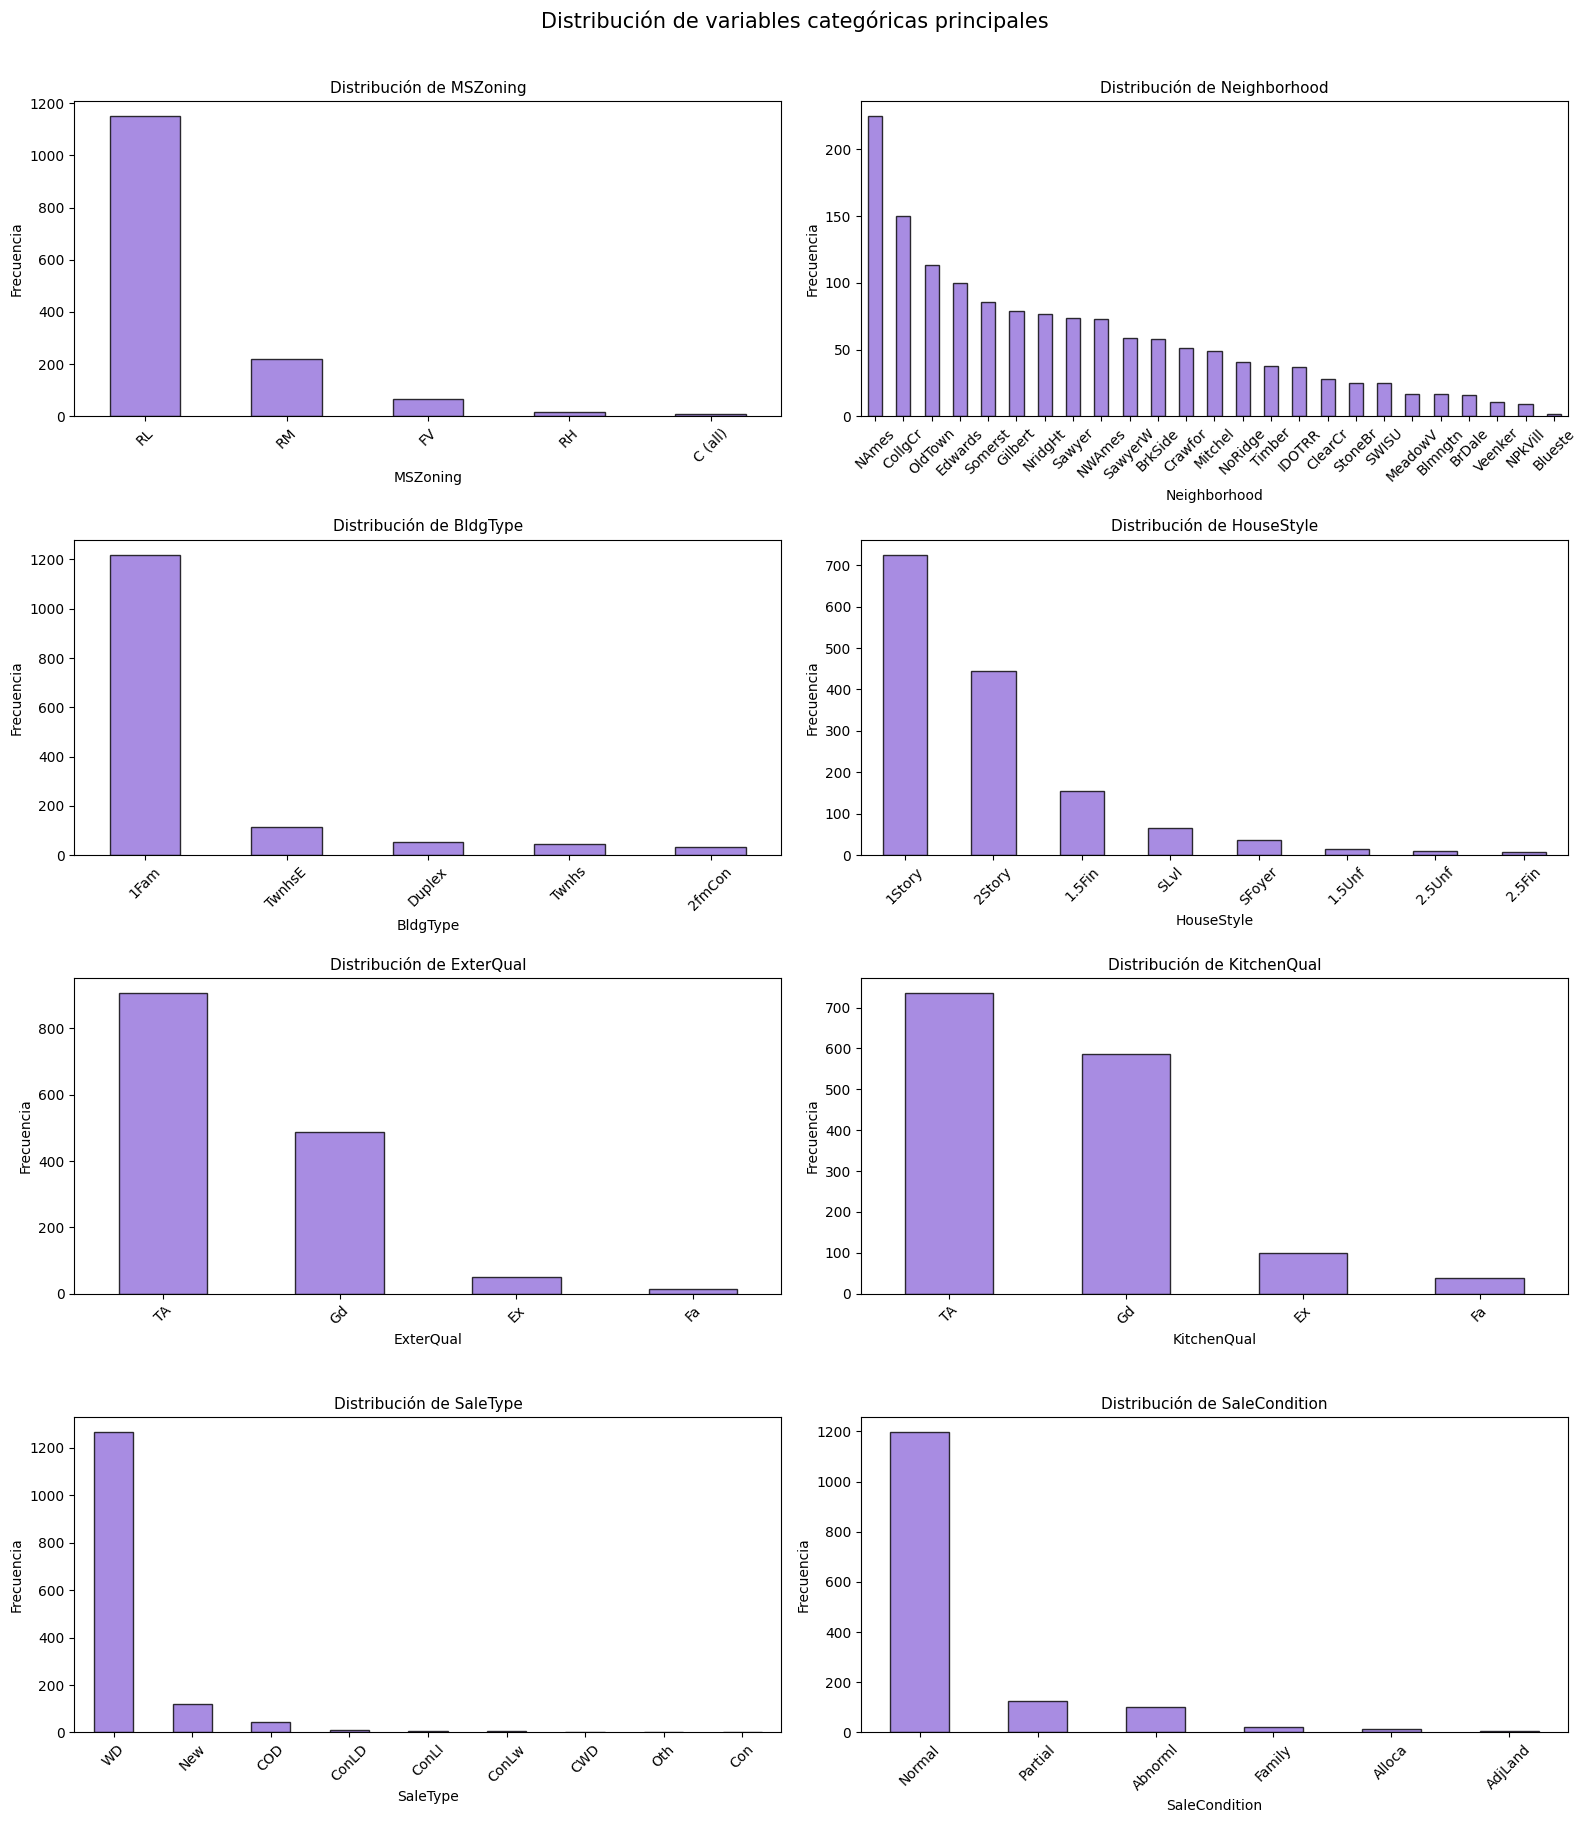

In [58]:
# Gráficos de barras para variables categóricas principales
cats_principales = ['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle', 
                    'ExterQual', 'KitchenQual', 'SaleType', 'SaleCondition']

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cats_principales):
    conteo = datos[col].value_counts()
    conteo.plot(kind='bar', ax=axes[i], color='mediumpurple', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribución de {col}', fontsize=11)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de variables categóricas principales', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 2.5 Matriz de correlación

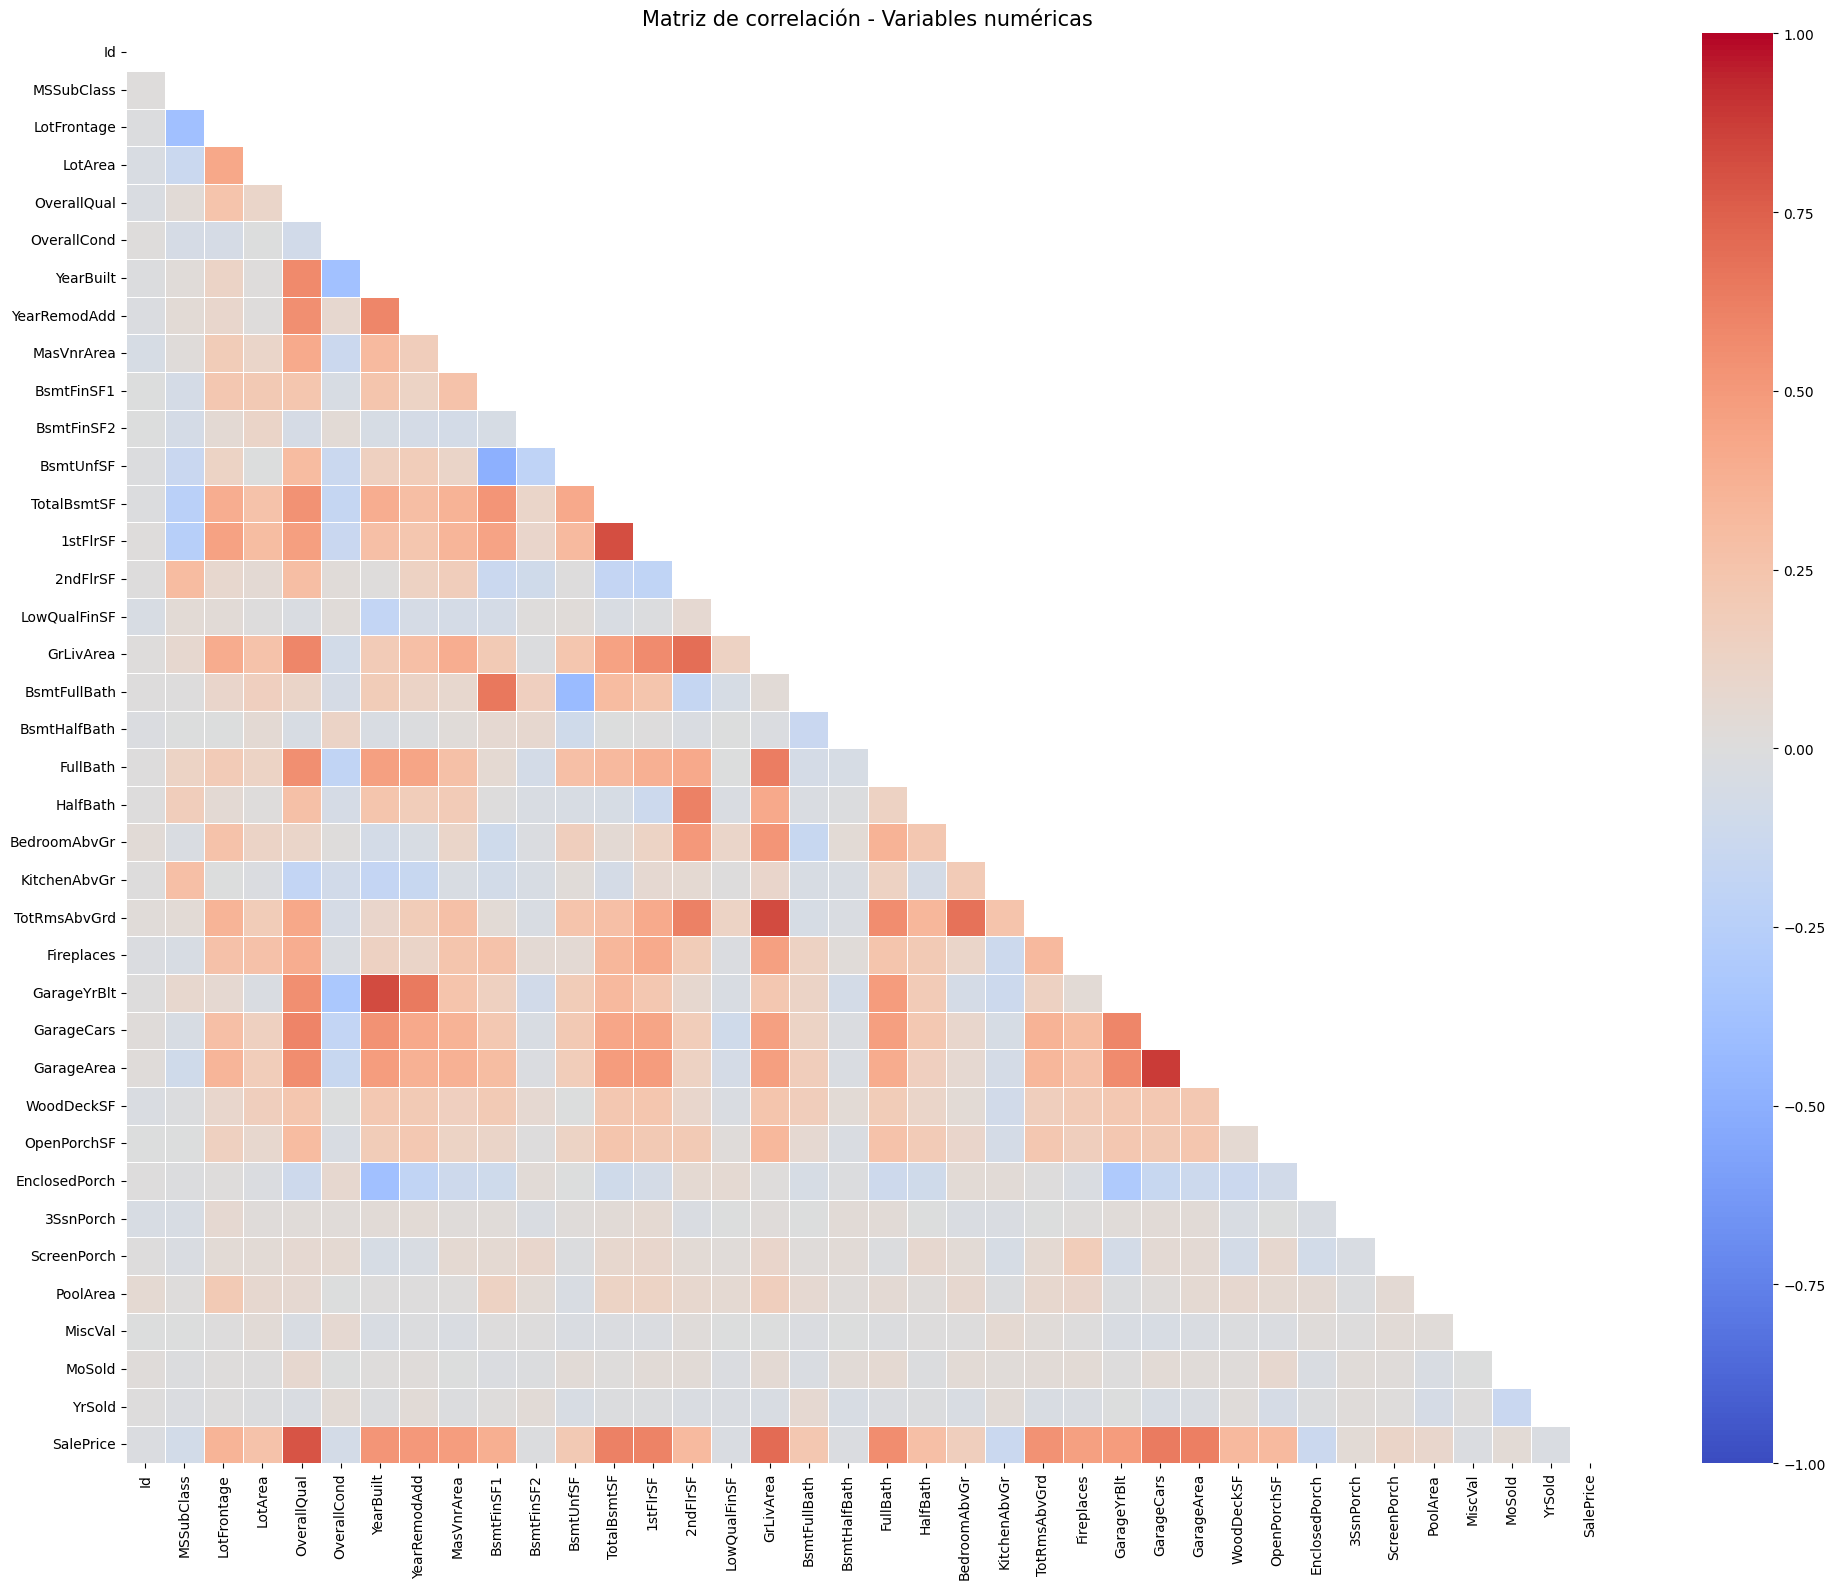

In [59]:
# Matriz de correlación de variables numéricas
corr = datos[numericas].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación - Variables numéricas', fontsize=15)
plt.tight_layout()
plt.show()

In [60]:
# Top correlaciones más fuertes (positivas y negativas)
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlación']
corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]
corr_pairs['Abs_Corr'] = corr_pairs['Correlación'].abs()
corr_pairs = corr_pairs.drop_duplicates(subset=['Abs_Corr']).sort_values('Abs_Corr', ascending=False)

print("Top 15 pares de variables con mayor correlación:")
print("=" * 60)
corr_pairs[['Variable 1', 'Variable 2', 'Correlación']].head(15)

Top 15 pares de variables con mayor correlación:


,Variable 1,Variable 2,Correlación
1015,GarageCars,GarageArea,0.882475
253,YearBuilt,GarageYrBlt,0.825667
631,GrLivArea,TotRmsAbvGrd,0.825489
469,TotalBsmtSF,1stFlrSF,0.819530
189,OverallQual,SalePrice,0.790982
645,GrLivArea,SalePrice,0.708624
548,2ndFlrSF,GrLivArea,0.687501
821,BedroomAbvGr,TotRmsAbvGrd,0.676620
359,BsmtFinSF1,BsmtFullBath,0.649212
291,YearRemodAdd,GarageYrBlt,0.642277


## 2.6 Análisis de outliers

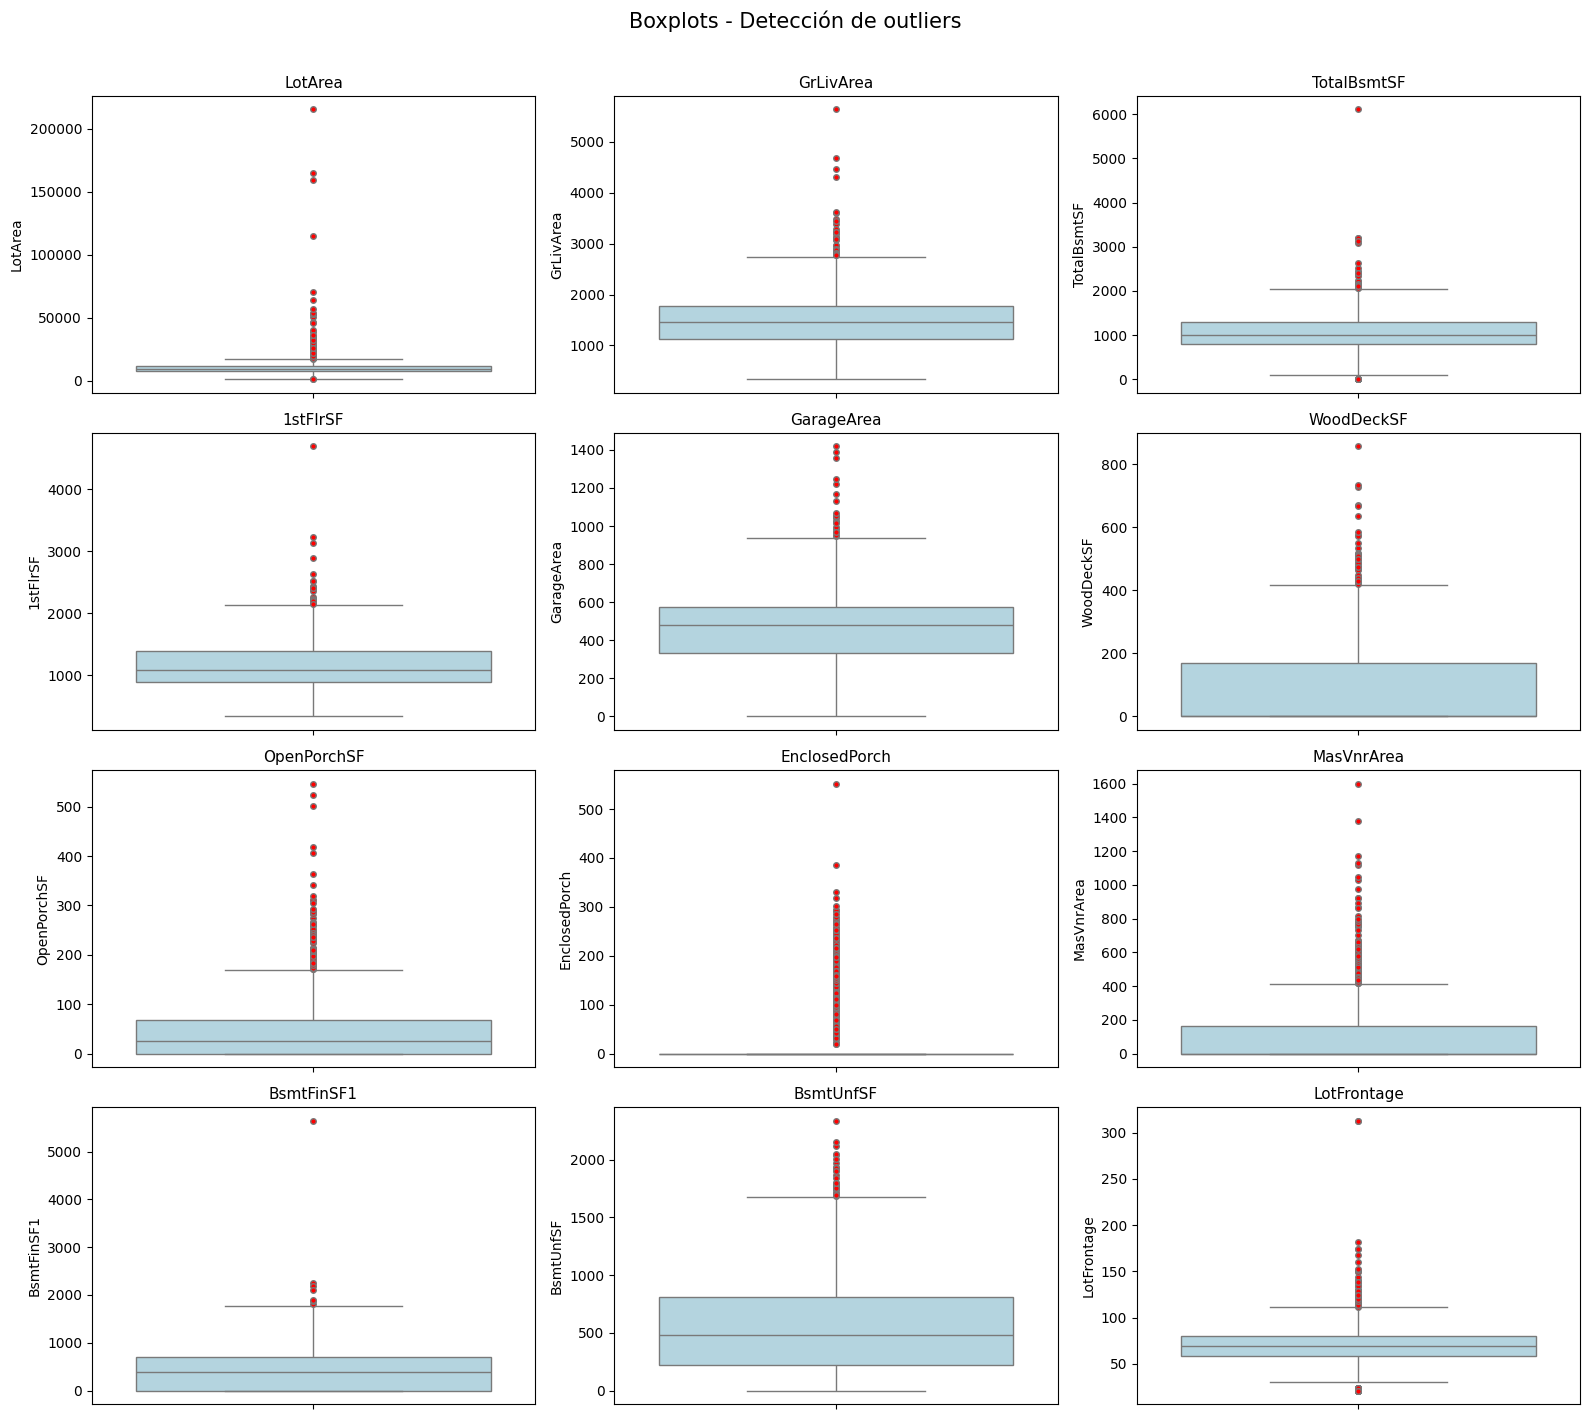

In [61]:
# Boxplots de variables numéricas clave para detectar outliers
vars_outliers = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 
                 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
                 'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'LotFrontage']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(vars_outliers):
    sns.boxplot(y=datos[col], ax=axes[i], color='lightblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplots - Detección de outliers', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [63]:
# Conteo de outliers usando el método IQR
print("Conteo de outliers por variable (método IQR):")
print("=" * 55)

for col in vars_outliers:
    datos_col = datos[col].dropna()
    Q1 = datos_col.quantile(0.25)
    Q3 = datos_col.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((datos_col < limite_inf) | (datos_col > limite_sup)).sum()
    pct = (n_outliers / len(datos_col) * 100)
    print(f"{col:20s} | Outliers: {n_outliers:4d} ({pct:.1f}%) | Rango válido: [{limite_inf:.1f}, {limite_sup:.1f}]")

Conteo de outliers por variable (método IQR):
LotArea              | Outliers:   69 (4.7%) | Rango válido: [1481.5, 17673.5]
GrLivArea            | Outliers:   31 (2.1%) | Rango válido: [158.6, 2747.6]
TotalBsmtSF          | Outliers:   61 (4.2%) | Rango válido: [42.0, 2052.0]
1stFlrSF             | Outliers:   20 (1.4%) | Rango válido: [118.1, 2155.1]
GarageArea           | Outliers:   21 (1.4%) | Rango válido: [-27.8, 938.2]
WoodDeckSF           | Outliers:   32 (2.2%) | Rango válido: [-252.0, 420.0]
OpenPorchSF          | Outliers:   77 (5.3%) | Rango válido: [-102.0, 170.0]
EnclosedPorch        | Outliers:  208 (14.2%) | Rango válido: [0.0, 0.0]
MasVnrArea           | Outliers:   96 (6.6%) | Rango válido: [-249.0, 415.0]
BsmtFinSF1           | Outliers:    7 (0.5%) | Rango válido: [-1068.4, 1780.6]
BsmtUnfSF            | Outliers:   29 (2.0%) | Rango válido: [-654.5, 1685.5]
LotFrontage          | Outliers:   88 (7.3%) | Rango válido: [27.5, 111.5]


## 2.7 Visualizaciones clave - Relaciones entre variables

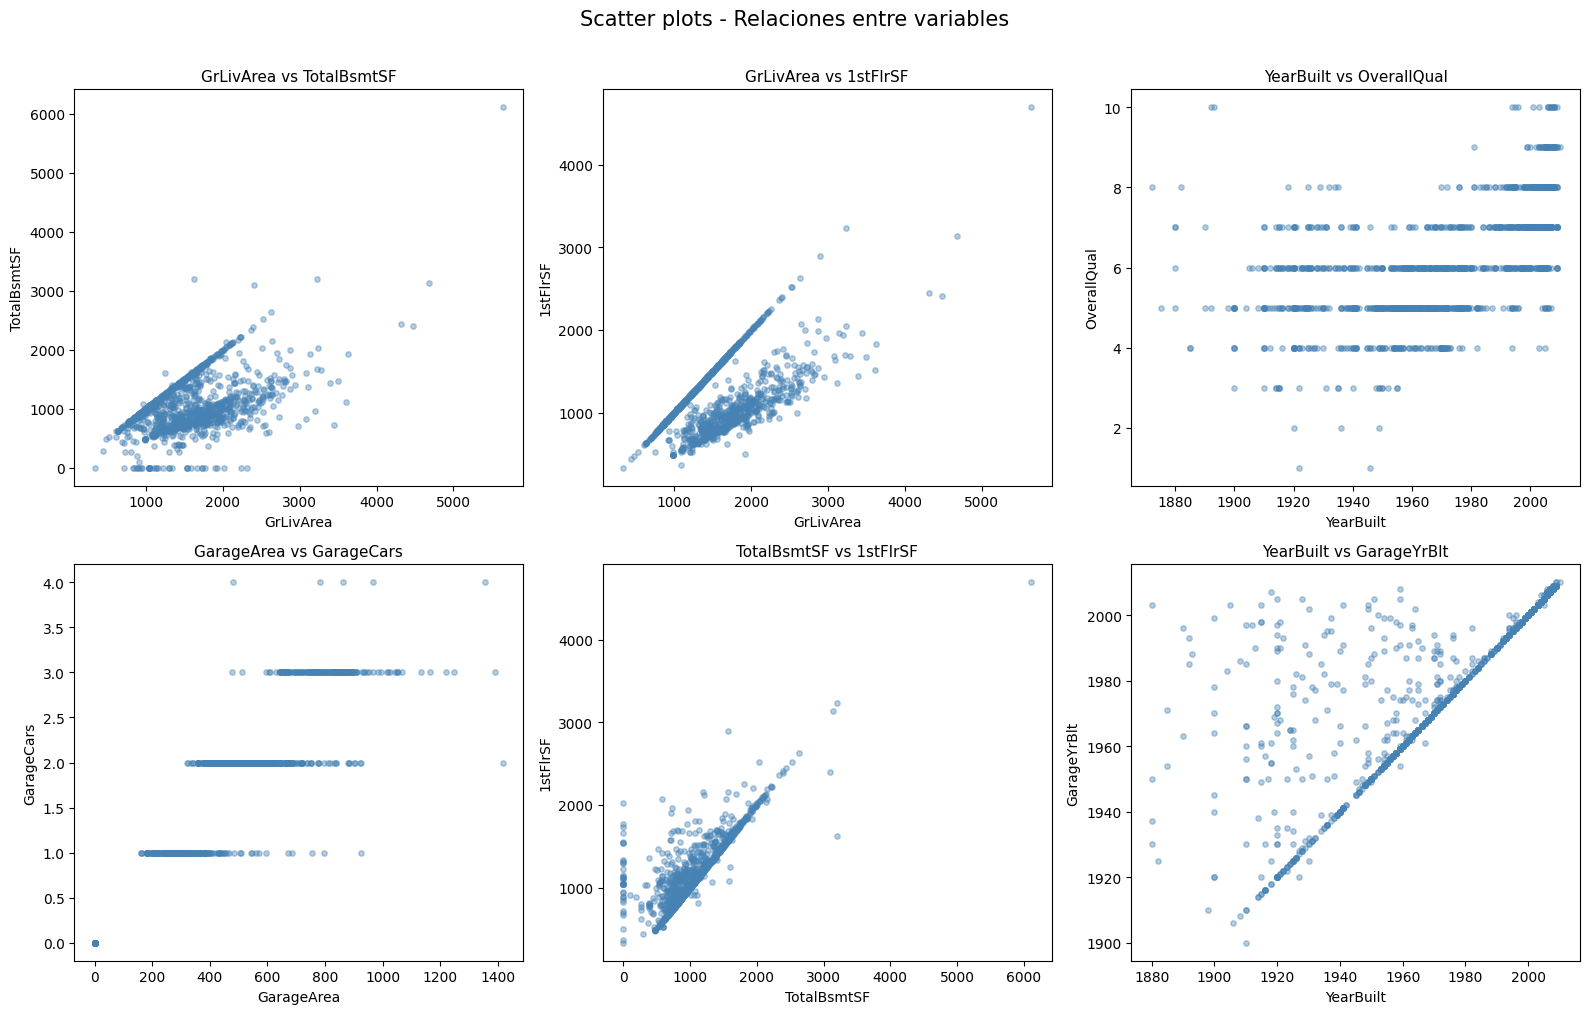

In [64]:
# Scatter plots: relaciones entre variables numéricas importantes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

pares = [
    ('GrLivArea', 'TotalBsmtSF'),
    ('GrLivArea', '1stFlrSF'),
    ('YearBuilt', 'OverallQual'),
    ('GarageArea', 'GarageCars'),
    ('TotalBsmtSF', '1stFlrSF'),
    ('YearBuilt', 'GarageYrBlt'),
]

for i, (x, y) in enumerate(pares):
    ax = axes[i // 3][i % 3]
    ax.scatter(datos[x], datos[y], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}', fontsize=11)

plt.suptitle('Scatter plots - Relaciones entre variables', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_22954/1647170054.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='GrLivArea', data=datos_filtrados, palette='Set2', ax=ax)


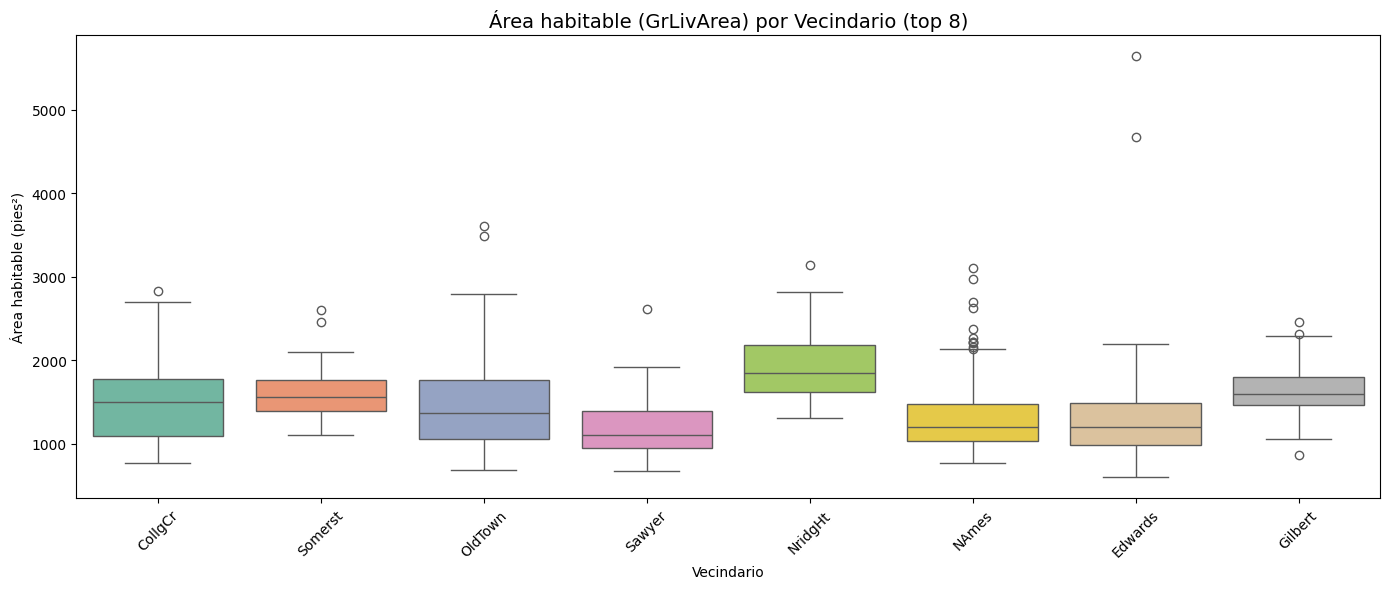

In [65]:
# Distribución de GrLivArea por Neighborhood  
top_barrios = datos['Neighborhood'].value_counts().head(8).index
datos_filtrados = datos[datos['Neighborhood'].isin(top_barrios)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='Neighborhood', y='GrLivArea', data=datos_filtrados, palette='Set2', ax=ax)
ax.set_title('Área habitable (GrLivArea) por Vecindario (top 8)', fontsize=14)
ax.set_xlabel('Vecindario')
ax.set_ylabel('Área habitable (pies²)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_22954/158077491.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='GrLivArea', data=datos, palette='viridis', ax=axes[1])


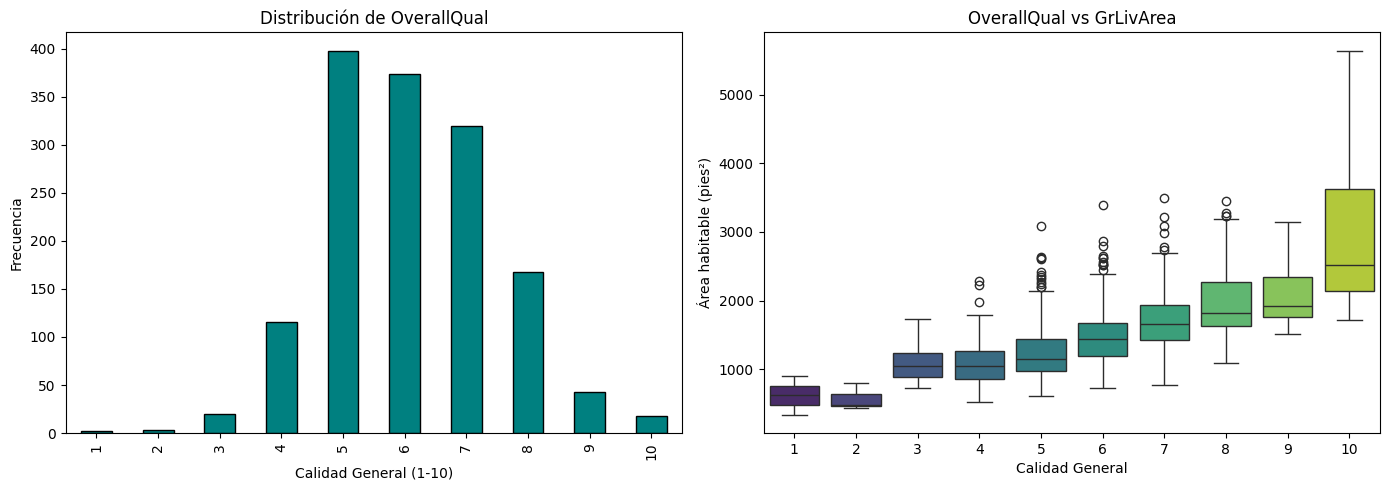

In [66]:
# OverallQual: distribución y relación con área
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de calidad general
datos['OverallQual'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Distribución de OverallQual', fontsize=12)
axes[0].set_xlabel('Calidad General (1-10)')
axes[0].set_ylabel('Frecuencia')

# Calidad general vs Área habitable
sns.boxplot(x='OverallQual', y='GrLivArea', data=datos, palette='viridis', ax=axes[1])
axes[1].set_title('OverallQual vs GrLivArea', fontsize=12)
axes[1].set_xlabel('Calidad General')
axes[1].set_ylabel('Área habitable (pies²)')

plt.tight_layout()
plt.show()

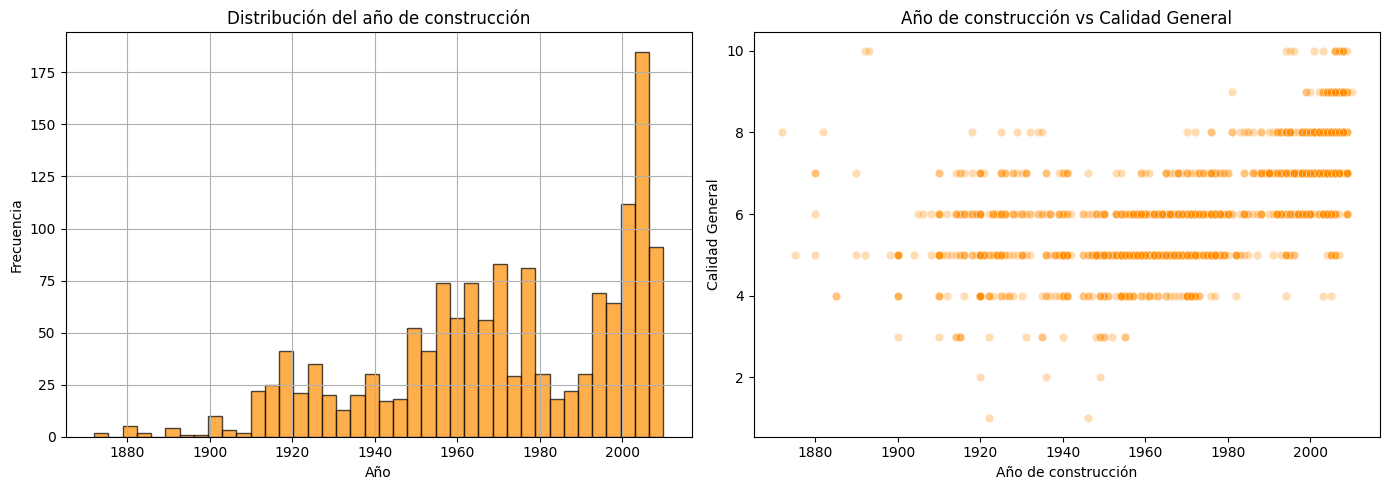

In [67]:
# Año de construcción a lo largo del tiempo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de año de construcción
datos['YearBuilt'].hist(bins=40, ax=axes[0], color='darkorange', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución del año de construcción', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Frecuencia')

# Año de construcción vs Calidad
sns.scatterplot(x='YearBuilt', y='OverallQual', data=datos, alpha=0.3, ax=axes[1], color='darkorange')
axes[1].set_title('Año de construcción vs Calidad General', fontsize=12)
axes[1].set_xlabel('Año de construcción')
axes[1].set_ylabel('Calidad General')

plt.tight_layout()
plt.show()

## 2.8 Análisis preparatorio para Regresión Lineal (usando train.csv)

Dimensiones train: (1460, 81)

Estadísticas de SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


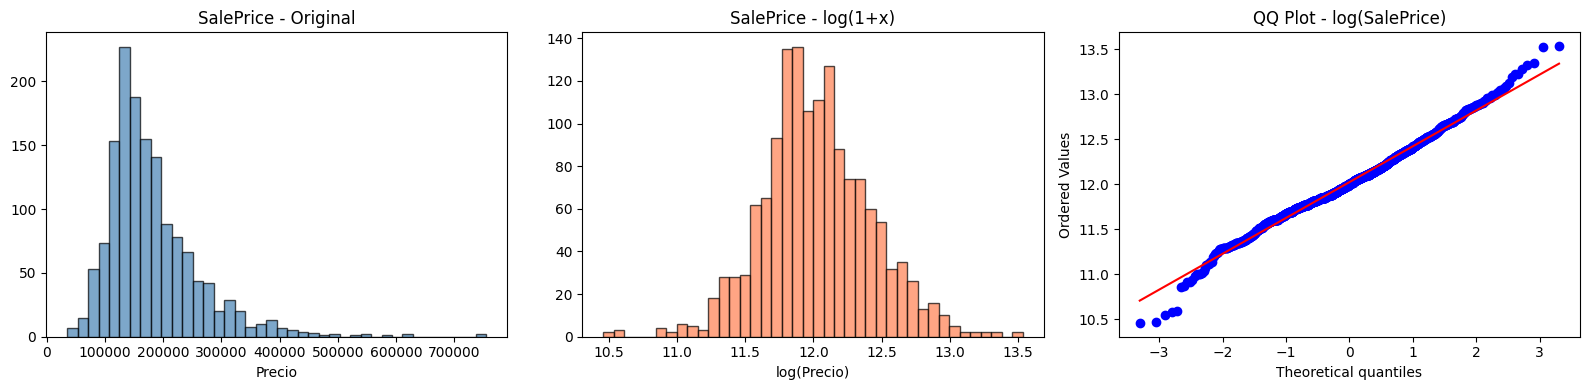


Shapiro-Wilk SalePrice original:     W=0.8290, p=0.000000
Shapiro-Wilk SalePrice log(1+x):     W=0.9861, p=0.000102
Skewness original: 1.883
Skewness log:      0.121


In [68]:
# Cargar train.csv para análisis con SalePrice
train = pd.read_csv('train.csv', sep=',', low_memory=False)
print(f"Dimensiones train: {train.shape}")
print(f"\nEstadísticas de SalePrice:")
print(train['SalePrice'].describe())

# Distribución de SalePrice
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train['SalePrice'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('SalePrice - Original')
axes[0].set_xlabel('Precio')

axes[1].hist(np.log1p(train['SalePrice']), bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('SalePrice - log(1+x)')
axes[1].set_xlabel('log(Precio)')

# QQ plot
from scipy.stats import probplot
probplot(np.log1p(train['SalePrice']), plot=axes[2])
axes[2].set_title('QQ Plot - log(SalePrice)')

plt.tight_layout()
plt.show()

# Shapiro test original vs transformado
stat_orig, p_orig = stats.shapiro(train['SalePrice'].sample(500, random_state=42))
stat_log, p_log = stats.shapiro(np.log1p(train['SalePrice']).sample(500, random_state=42))
print(f"\nShapiro-Wilk SalePrice original:     W={stat_orig:.4f}, p={p_orig:.6f}")
print(f"Shapiro-Wilk SalePrice log(1+x):     W={stat_log:.4f}, p={p_log:.6f}")
print(f"Skewness original: {train['SalePrice'].skew():.3f}")
print(f"Skewness log:      {np.log1p(train['SalePrice']).skew():.3f}")

Top 15 variables numéricas más correlacionadas con SalePrice:
  OverallQual          | r = +0.7910
  GrLivArea            | r = +0.7086
  GarageCars           | r = +0.6404
  GarageArea           | r = +0.6234
  TotalBsmtSF          | r = +0.6136
  1stFlrSF             | r = +0.6059
  FullBath             | r = +0.5607
  TotRmsAbvGrd         | r = +0.5337
  YearBuilt            | r = +0.5229
  YearRemodAdd         | r = +0.5071
  GarageYrBlt          | r = +0.4864
  MasVnrArea           | r = +0.4775
  Fireplaces           | r = +0.4669
  BsmtFinSF1           | r = +0.3864
  LotFrontage          | r = +0.3518


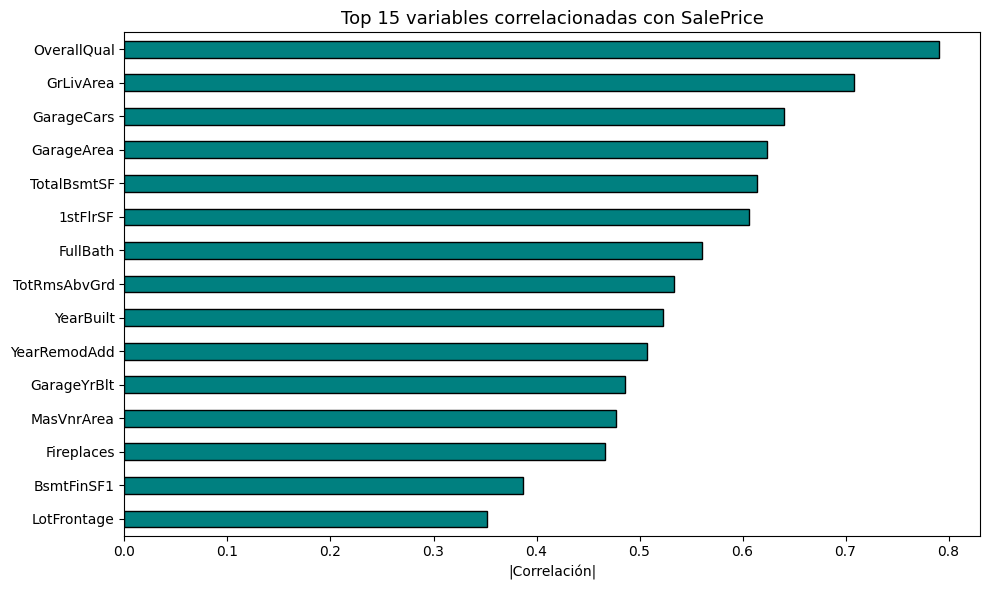

In [69]:
# 1. Variables más predictivas del precio (correlación con SalePrice)
num_train = train.select_dtypes(include=[np.number])
corr_price = num_train.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

print("Top 15 variables numéricas más correlacionadas con SalePrice:")
print("=" * 55)
for var, val in corr_price.head(15).items():
    signo = "+" if num_train.corr()['SalePrice'][var] > 0 else "-"
    print(f"  {var:20s} | r = {signo}{val:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
corr_price.head(15).plot(kind='barh', color='teal', edgecolor='black', ax=ax)
ax.set_title('Top 15 variables correlacionadas con SalePrice', fontsize=13)
ax.set_xlabel('|Correlación|')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

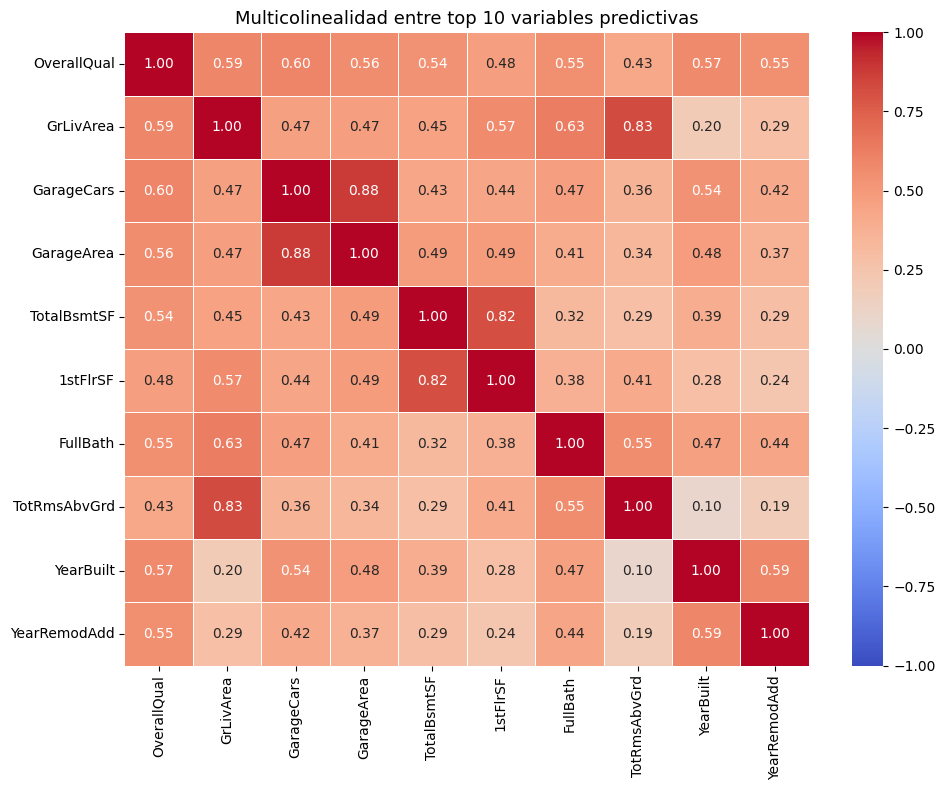


Pares con alta multicolinealidad (|r| > 0.7):
  GrLivArea            <-> TotRmsAbvGrd         | r = 0.825
  GarageCars           <-> GarageArea           | r = 0.882
  TotalBsmtSF          <-> 1stFlrSF             | r = 0.820


In [70]:
# 2. Análisis de multicolinealidad entre las top variables predictivas
top_vars = corr_price.head(10).index.tolist()
corr_top = num_train[top_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Multicolinealidad entre top 10 variables predictivas', fontsize=13)
plt.tight_layout()
plt.show()

# Pares con alta multicolinealidad (|r| > 0.7)
print("\nPares con alta multicolinealidad (|r| > 0.7):")
print("=" * 55)
for i in range(len(top_vars)):
    for j in range(i+1, len(top_vars)):
        r = corr_top.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {top_vars[i]:20s} <-> {top_vars[j]:20s} | r = {r:.3f}")

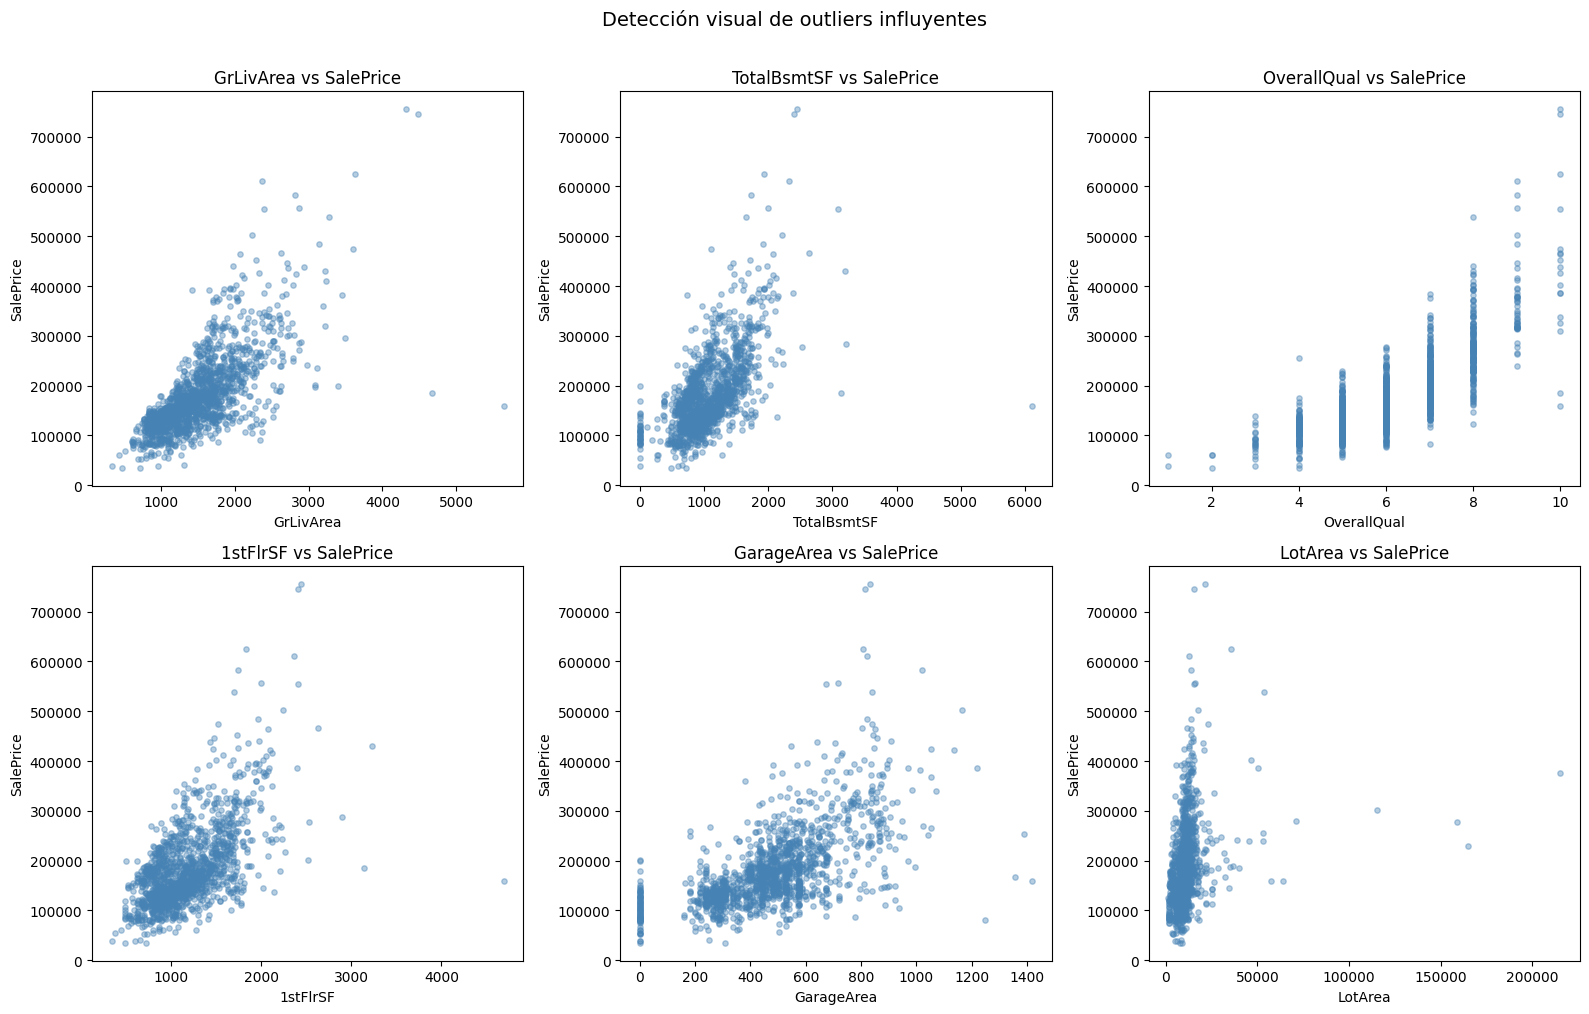


Outliers influyentes en GrLivArea (área > 4000 y precio < 300k):
  Id  GrLivArea  SalePrice  OverallQual
 524       4676     184750           10
1299       5642     160000           10

Outliers extremos en LotArea (> 100,000 sqft):
 Id  LotArea  SalePrice
250   159000     277000
314   215245     375000
336   164660     228950
707   115149     302000


In [71]:
# 3. Outliers que afectan el modelo (scatter vs SalePrice)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

vars_scatter = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', '1stFlrSF', 'GarageArea', 'LotArea']
for i, var in enumerate(vars_scatter):
    axes[i].scatter(train[var], train['SalePrice'], alpha=0.4, s=15, color='steelblue')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{var} vs SalePrice')

plt.suptitle('Detección visual de outliers influyentes', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Identificar outliers extremos en GrLivArea (los más conocidos en este dataset)
outliers_grliv = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(f"\nOutliers influyentes en GrLivArea (área > 4000 y precio < 300k):")
print(outliers_grliv[['Id', 'GrLivArea', 'SalePrice', 'OverallQual']].to_string(index=False))

outliers_lot = train[train['LotArea'] > 100000]
print(f"\nOutliers extremos en LotArea (> 100,000 sqft):")
print(outliers_lot[['Id', 'LotArea', 'SalePrice']].to_string(index=False))

In [72]:
# 4. Tratamiento de NA - Resumen y estrategia
nulos_train = train.isnull().sum()
pct_nulos_train = (nulos_train / len(train) * 100).round(2)
nulos_train_df = pd.DataFrame({
    'Nulos': nulos_train[nulos_train > 0],
    '%': pct_nulos_train[pct_nulos_train > 0],
    'Tipo': train[nulos_train[nulos_train > 0].index].dtypes
}).sort_values('%', ascending=False)

# Clasificar estrategia de tratamiento
def estrategia_na(row):
    if row['%'] > 40:
        return 'ELIMINAR columna (>40% nulos)'
    elif row['Tipo'] == 'object':
        return 'Imputar con "None" o moda'
    else:
        return 'Imputar con mediana/0'

nulos_train_df['Estrategia'] = nulos_train_df.apply(estrategia_na, axis=1)
print("Estrategia de tratamiento de valores nulos (train):")
print("=" * 80)
nulos_train_df

Estrategia de tratamiento de valores nulos (train):


,Nulos,%,Tipo,Estrategia
PoolQC,1453,99.52,str,ELIMINAR columna (>40% nulos)
MiscFeature,1406,96.30,str,ELIMINAR columna (>40% nulos)
Alley,1369,93.77,str,ELIMINAR columna (>40% nulos)
Fence,1179,80.75,str,ELIMINAR columna (>40% nulos)
MasVnrType,872,59.73,str,ELIMINAR columna (>40% nulos)
FireplaceQu,690,47.26,str,ELIMINAR columna (>40% nulos)
LotFrontage,259,17.74,float64,Imputar con mediana/0
GarageType,81,5.55,str,Imputar con mediana/0
GarageYrBlt,81,5.55,float64,Imputar con mediana/0
GarageFinish,81,5.55,str,Imputar con mediana/0


# 3.Análisis de Grupos

In [8]:
vars_cluster = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "GarageYrBlt",
    "MasVnrArea",
    "Fireplaces",
    "BsmtFinSF1",
    "LotFrontage"
]

X = datos[vars_cluster].copy()

# Para null
X = X.fillna(X.median())



In [9]:
#Escalar variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


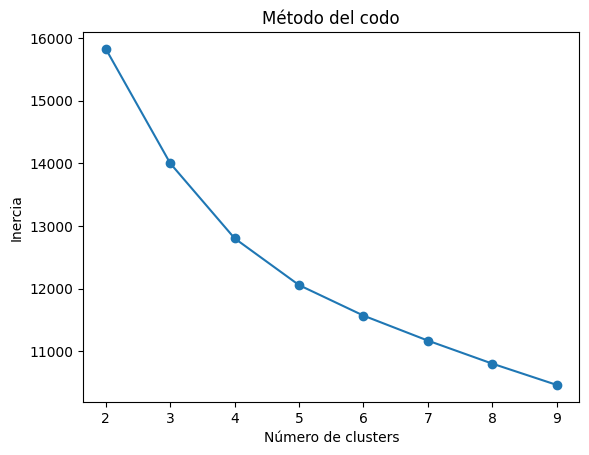

In [10]:
#Número óptimo de clusters
from sklearn.cluster import KMeans

inertia = []
K = range(2,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()


In [12]:
#K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_cluster = datos.copy()
df_cluster["Cluster"] = clusters

df_cluster.groupby("Cluster")[vars_cluster + ["SalePrice"]].mean()


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1,LotFrontage,SalePrice
Cluster,,,,,,,,,,,,,,,,
0,4.956633,1136.068878,0.877551,239.920918,772.341837,900.877551,1.130102,5.635204,1945.395408,1969.885204,1953.384127,25.989796,0.239796,256.729592,59.543605,115138.140306
1,5.326360,1101.828452,1.895397,528.824268,978.071130,1041.995816,1.046025,5.297071,1967.757322,1980.610879,1978.033473,63.617647,0.347280,576.276151,70.121547,142445.301255
2,8.145833,2210.802083,2.729167,757.958333,1665.880208,1694.697917,2.088542,8.234375,1997.213542,2001.031250,1999.421875,354.542105,1.130208,826.401042,91.687861,322683.093750
3,5.832000,1829.016000,1.808000,475.408000,1083.344000,1337.832000,1.692000,7.608000,1951.860000,1975.172000,1960.825203,114.968000,1.092000,441.584000,79.133690,177245.444000
4,6.891473,1607.682171,2.085271,531.609819,1076.602067,1125.100775,1.984496,6.609819,1999.307494,2000.909561,2000.108527,76.222513,0.589147,362.483204,64.224684,203358.793282


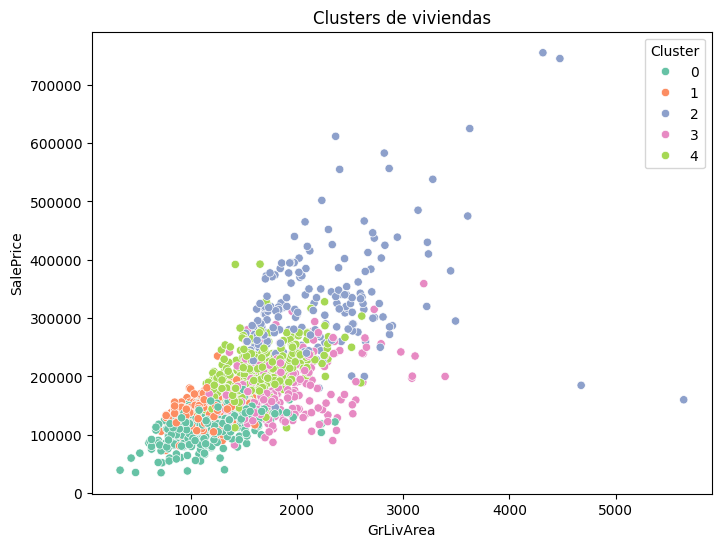

In [13]:
#Visualizar grupos
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_cluster,
    x="GrLivArea",
    y="SalePrice",
    hue="Cluster",
    palette="Set2"
)
plt.title("Clusters de viviendas")
plt.show()


# 4. Separar train y test

In [14]:
X = datos.drop(columns=["SalePrice"])
y = datos["SalePrice"]


In [16]:
#Dividir dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


print("Filas en entrenamiento:", X_train.shape[0])
print("Filas en prueba:", X_test.shape[0])


Filas en entrenamiento: 1168
Filas en prueba: 292


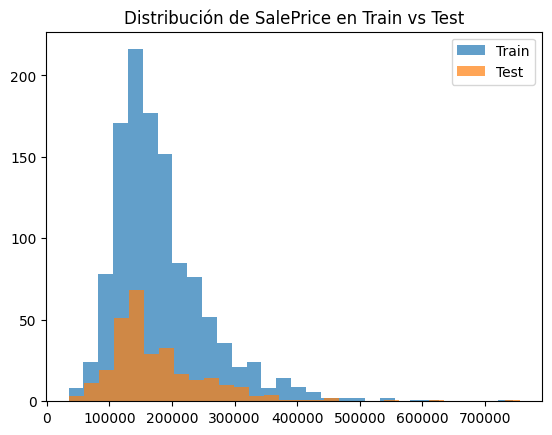

In [17]:
#Distribución de precio

plt.hist(y_train, bins=30, alpha=0.7, label="Train")
plt.hist(y_test, bins=30, alpha=0.7, label="Test")

plt.legend()
plt.title("Distribución de SalePrice en Train vs Test")
plt.show()


In [18]:
#Guardar datasets
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)
